# Session-Based Recommendations with Graph Neural Networks
### A visual walkthrough: how understanding the data leads us to graphs, and then to a graph transformer

**The question this project answers:** an anonymous shopper has clicked on a few items in the last few minutes. What will they look at, or buy, next?

This notebook is a story told in three moves:

1. **Understand the data** &nbsp;-&nbsp; what we actually have, and what is missing
2. **Why graph networks** &nbsp;-&nbsp; what about this data forces us onto a graph
3. **Why a graph transformer** &nbsp;-&nbsp; why simpler graph models are not enough here

Every design choice downstream (the graph, the model, the math, the training, the serving) will trace back to something we see in the data. If a choice cannot be traced back to the data, it does not belong.

This first part is only about the data. No models yet.


## Part 1. Understand the data

The dataset is the **RetailRocket** e-commerce event log: every view, add-to-cart, and purchase on a real online store, recorded over about four and a half months. We load it and let it speak before we decide anything.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# One consistent look for the whole story.
mpl.rcParams.update({
    "figure.figsize": (8, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "font.size": 11,
})
INK, ACCENT, HILITE, MUTED = "#0f172a", "#4f46e5", "#e11d48", "#cbd5e1"

def find_repo_root(start: Path = None) -> Path:
    """Walk up from the current directory until we find the project root."""
    p = (start or Path.cwd()).resolve()
    for _ in range(6):
        if (p / "pyproject.toml").exists() and (p / "etpgt").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = find_repo_root()
events = pd.read_csv(ROOT / "data" / "raw" / "events.csv")
print(f"Loaded {len(events):,} events")
events.head()

Loaded 2,756,101 events


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


Each row is a single event. Five columns:

- `timestamp`: when it happened, in Unix milliseconds
- `visitorid`: an anonymous id for the browser or device
- `event`: one of `view`, `addtocart`, `transaction`
- `itemid`: the product involved
- `transactionid`: filled in only when the event is an actual purchase

There is no name, no profile, no history beyond what this log contains. That constraint turns out to be the whole story. Let's make it visible.


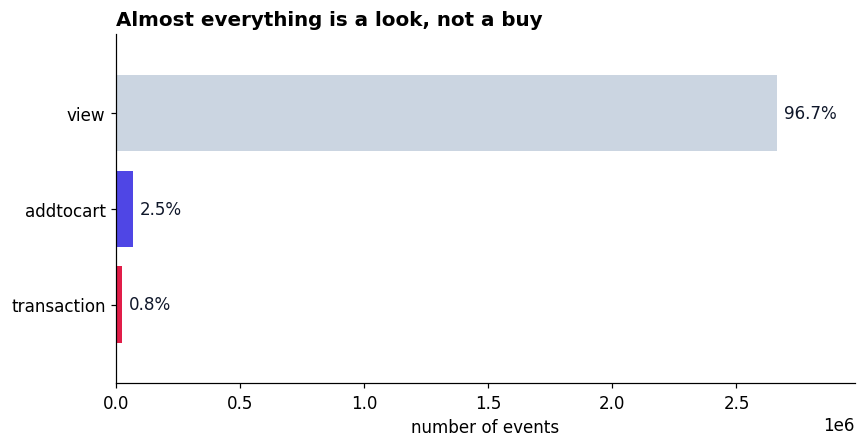

In [2]:
n = len(events)
mix = events["event"].value_counts().reindex(["view", "addtocart", "transaction"])
pct = mix / n * 100

fig, ax = plt.subplots()
colors = [MUTED, ACCENT, HILITE]
bars = ax.barh(mix.index[::-1], mix.values[::-1], color=colors[::-1])
for bar, p in zip(bars, pct.values[::-1]):
    ax.text(bar.get_width() + n * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{p:.1f}%", va="center", fontsize=11, color=INK)
ax.set_title("Almost everything is a look, not a buy")
ax.set_xlabel("number of events")
ax.set_xlim(0, n * 1.08)
ax.margins(y=0.15)
plt.tight_layout(); plt.show()

Only about **0.8 percent** of events are purchases. The signal we are handed is overwhelmingly browsing behavior, while the thing we actually care about, a purchase, is rare. A model that learned only from purchases would starve. **We have to learn from the browsing itself.**


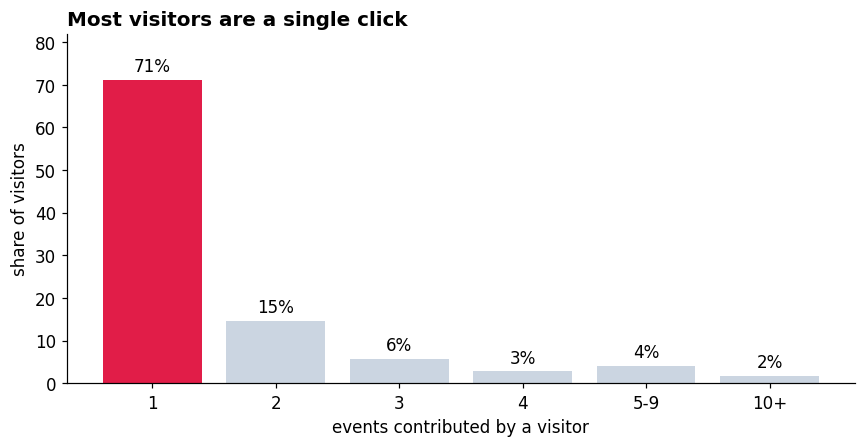

unique visitors : 1,407,580
unique items    : 235,061
events / visitor: 1.96 (mean)


In [3]:
per_visitor = events.groupby("visitorid").size()
buckets = pd.cut(per_visitor, bins=[0, 1, 2, 3, 4, 9, 1e9],
                 labels=["1", "2", "3", "4", "5-9", "10+"]).value_counts().sort_index()
share = buckets / buckets.sum() * 100

fig, ax = plt.subplots()
colors = [HILITE if lab == "1" else MUTED for lab in buckets.index]
bars = ax.bar(buckets.index.astype(str), share.values, color=colors)
ax.bar_label(ax.containers[0], labels=[f"{s:.0f}%" for s in share.values], padding=3)
ax.set_title("Most visitors are a single click")
ax.set_xlabel("events contributed by a visitor")
ax.set_ylabel("share of visitors")
ax.set_ylim(0, share.max() * 1.15)
plt.tight_layout(); plt.show()

print(f"unique visitors : {events['visitorid'].nunique():,}")
print(f"unique items    : {events['itemid'].nunique():,}")
print(f"events / visitor: {per_visitor.mean():.2f} (mean)")

This is the pivot of the entire project.

Nearly **three quarters of visitors appear exactly once**, and on average a visitor gives us fewer than two events. There is no meaningful per-user history to learn from, and the ids are anonymous, so nothing carries across visits even in principle.

The consequence: **we cannot model people.** We can only model the short trail of clicks in front of us right now (the *session*) and the relationships *between items*. Hold onto that phrase, "relationships between items". It is the seed of Part 2.


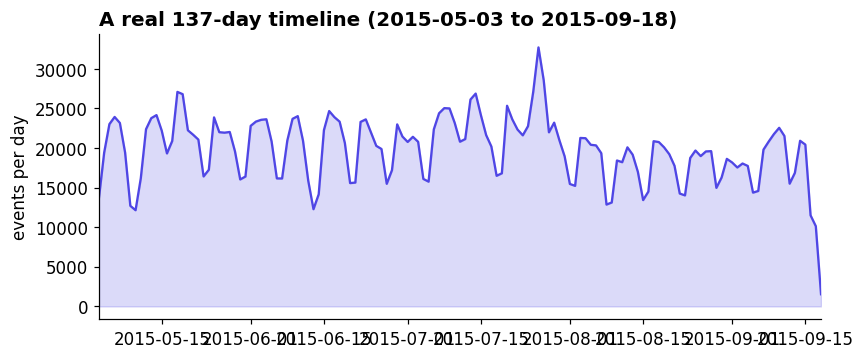

In [4]:
ts = pd.to_datetime(events["timestamp"], unit="ms")
daily = ts.dt.floor("D").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.fill_between(daily.index, daily.values, color=ACCENT, alpha=0.20)
ax.plot(daily.index, daily.values, color=ACCENT, linewidth=1.5)
ax.set_title(f"A real 137-day timeline ({daily.index.min().date()} to {daily.index.max().date()})")
ax.set_ylabel("events per day")
ax.margins(x=0)
plt.tight_layout(); plt.show()

Shopping behavior lives in time. Trends come and go, and a recommender in production only ever sees the past and predicts the future. We will respect that later by splitting the data **by time** rather than at random. For now, just note that the data has a genuine timeline.

### What the data has told us so far

| What we see in the data | What it forces |
| --- | --- |
| 96.7% views, 0.8% purchases | Learn from browsing, not only from purchases |
| 71% of visitors appear once, ids anonymous | Cannot model users. Model **sessions and items** instead |
| A clear 137-day timeline | Split by time, never randomly (done in a later step) |

We are left with one usable idea: **items, and the way they relate to each other inside a session.** That is exactly what a graph is for. Part 2 turns this into a graph and explains why a graph *neural network* is the natural model for it.


---
## Part 2. Why graph networks

Part 1 left us with a single usable idea: **items, and how they relate to each other inside a session.** We have no users to model, only the short trails of clicks and the co-occurrences inside them.

A structure whose entire job is to hold "things and the relationships between them" is a **graph**. This part builds that graph from the real data, then shows why a *neural network that runs on a graph* is the natural fit for it.

We do it in four moves: events to sessions, one session to edges, all sessions to a graph, and finally graph to a graph neural network.


### 2.1 Events become sessions

A raw event log has no notion of a "visit". We cut it into **sessions** with two rules, the same ones the project uses:

- **30-minute gap:** if a visitor is idle for more than 30 minutes, the next event begins a new session. Short gaps are the same shopping intent (switching tabs, reading a review). A long gap is probably a different visit.
- **Minimum 3 events:** a session with one or two events has no internal structure to learn from. Three is the smallest visit that gives us at least one edge in the graph.


In [5]:
import numpy as np
import networkx as nx

GAP_MS = 30 * 60 * 1000   # 30 minutes
MIN_LEN = 3

s = events.sort_values(["visitorid", "timestamp"]).reset_index(drop=True)
gap = s.groupby("visitorid")["timestamp"].diff()
s["session_id"] = (gap.isna() | (gap > GAP_MS)).cumsum()          # new session on gap or new visitor
lengths = s.groupby("session_id").size()
sessions = s[s["session_id"].isin(lengths[lengths >= MIN_LEN].index)].copy()

slen = sessions.groupby("session_id").size()
print(f"sessions           : {sessions['session_id'].nunique():,}")
print(f"events kept        : {len(sessions):,}  ({len(sessions) / len(events) * 100:.1f}% of raw)")
print(f"session length     : mean {slen.mean():.2f}   median {slen.median():.0f}   max {slen.max()}")

sessions           : 172,066
events kept        : 955,778  (34.7% of raw)
session length     : mean 5.55   median 4   max 417


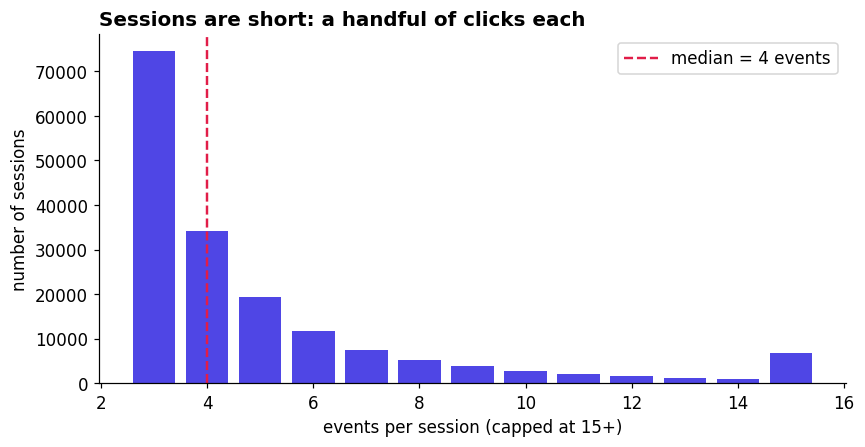

In [6]:
cap = 15
capped = slen.clip(upper=cap).value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(capped.index, capped.values, color=ACCENT)
ax.axvline(slen.median(), color=HILITE, linestyle="--", linewidth=1.6,
           label=f"median = {slen.median():.0f} events")
ax.set_title("Sessions are short: a handful of clicks each")
ax.set_xlabel(f"events per session (capped at {cap}+)")
ax.set_ylabel("number of sessions")
ax.legend()
plt.tight_layout(); plt.show()

The typical visit is only about four events long. Remember this number. It is exactly why, in a moment, we connect items within a small window of five steps: a window of five reaches across almost the whole of a normal session, without stitching together items from opposite ends of a rare long one.


### 2.2 A single session becomes edges

Here is the core move. Inside a session, items that appear close together are related, someone looking at one was, moments later, interested in the other. We turn that into an edge.

The rule: connect each item to the next few items after it, up to a **window of 5 steps**. Edges are undirected (co-occurrence has no direction) and we count how often each pair shows up. Watch it happen on one real session.


In [7]:
# pick one short, readable real session
info = sessions.groupby("session_id")["itemid"].agg(["size", "nunique"])
sid = info[(info["size"].between(4, 5)) & (info["nunique"] >= 4)].index[0]
seq = sessions.loc[sessions["session_id"] == sid, "itemid"].tolist()

print(f"session {sid} click sequence:")
print("   " + "  ->  ".join(str(i) for i in seq))

W = 5
edges_here = set()
for i in range(len(seq)):
    for j in range(i + 1, min(i + W + 1, len(seq))):
        edges_here.add(tuple(sorted((seq[i], seq[j]))))
print(f"\nedges produced (window {W}):")
for a, b in sorted(edges_here):
    print(f"   {a} -- {b}")

session 84 click sequence:
   295653  ->  233200  ->  118401  ->  224700  ->  160984

edges produced (window 5):
   118401 -- 160984
   118401 -- 224700
   118401 -- 233200
   118401 -- 295653
   160984 -- 224700
   160984 -- 233200
   160984 -- 295653
   224700 -- 233200
   224700 -- 295653
   233200 -- 295653


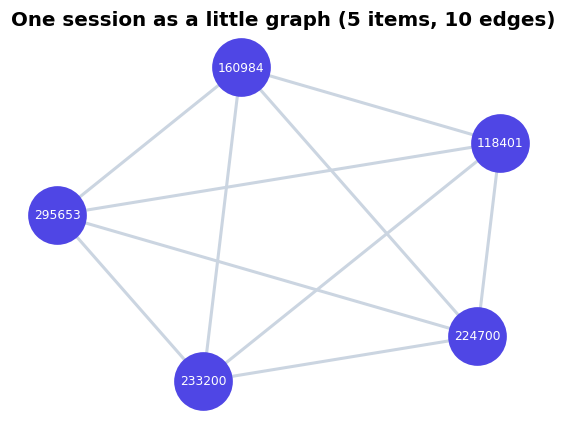

In [8]:
g = nx.Graph(); g.add_edges_from(edges_here)
fig, ax = plt.subplots(figsize=(5.2, 4))
pos = nx.spring_layout(g, seed=42, k=1.2)
nx.draw_networkx_edges(g, pos, edge_color=MUTED, width=2, ax=ax)
nx.draw_networkx_nodes(g, pos, node_color=ACCENT, node_size=1400, ax=ax)
nx.draw_networkx_labels(g, pos, font_size=8, font_color="white", ax=ax)
ax.set_title(f"One session as a little graph ({len(g)} items, {g.number_of_edges()} edges)")
ax.axis("off")
plt.tight_layout(); plt.show()

One visit, one tiny graph. Now imagine overlaying every training session on top of each other: shared items become shared nodes, and repeated co-occurrences pile up as heavier edges. That accumulation is the item graph.


### 2.3 All sessions become one item graph

We build the graph from **training sessions only.** If we used future sessions, the model would learn co-occurrence patterns from the very period we test on, and our results would be a fantasy. We split the data by time first (the detailed reasoning for the split lives in the evaluation part) and keep only the earliest 70 percent for building the graph.


In [9]:
# temporal split (mirrors the project); keep training sessions only so the graph never peeks at the future
st = sessions.groupby("session_id")["timestamp"].agg(["min", "max"]).reset_index()
st.columns = ["session_id", "start", "end"]
st = st.sort_values("start").reset_index(drop=True)
N = len(st)
train_end = st.iloc[int(N * 0.70) - 1]["end"]
BLACKOUT = 2 * 24 * 60 * 60 * 1000                       # 2-day gap after training
train_ids = set(st.loc[st["end"] <= train_end, "session_id"])
train = sessions[sessions["session_id"].isin(train_ids)].copy()
print(f"training sessions used to build the graph: {len(train_ids):,}")

# build the co-occurrence graph: forward window of 5, undirected, counted
W = 5
lo, hi = [], []
for _, grp in train.groupby("session_id", sort=False):
    it = grp["itemid"].to_numpy()                        # already time-ordered
    for d in range(1, W + 1):
        if d >= len(it):
            break
        a, b = it[:-d], it[d:]
        lo.append(np.minimum(a, b)); hi.append(np.maximum(a, b))
pairs = pd.DataFrame({"i": np.concatenate(lo), "j": np.concatenate(hi)})
edges = pairs.groupby(["i", "j"], sort=False).size().reset_index(name="count")

num_nodes = len(pd.unique(edges[["i", "j"]].values.ravel()))
num_edges = len(edges)
print(f"nodes (items)      : {num_nodes:,}")
print(f"edges              : {num_edges:,}")
print(f"average degree     : {2 * num_edges / num_nodes:.2f}")
print(f"edge weight        : median {edges['count'].median():.0f}   max {edges['count'].max():,}")

training sessions used to build the graph: 120,436


nodes (items)      : 82,173
edges              : 737,713
average degree     : 17.96
edge weight        : median 1   max 1,424


Tens of thousands of items, hundreds of thousands of edges, and an average item connected to only about eighteen others. The graph is **sparse**, and it is far from uniform. Look at how the connections are distributed.


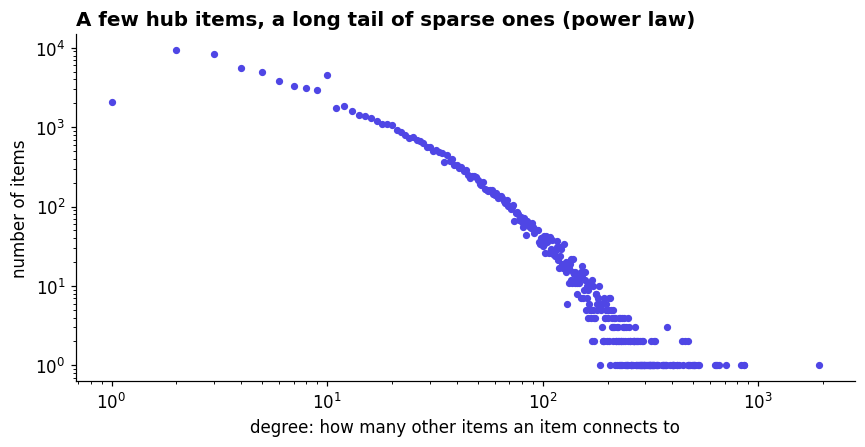

In [10]:
deg = pd.concat([edges["i"], edges["j"]]).value_counts()       # edges incident to each item
dist = deg.value_counts().sort_index()

fig, ax = plt.subplots()
ax.scatter(dist.index, dist.values, s=14, color=ACCENT)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("A few hub items, a long tail of sparse ones (power law)")
ax.set_xlabel("degree: how many other items an item connects to")
ax.set_ylabel("number of items")
plt.tight_layout(); plt.show()

A near-straight line on log-log axes is the signature of a **power law**: a small number of hub items (popular products) connect to hundreds of others, while most items sit in a long tail with only a handful of connections. This shape matters later. It is part of why a model that can look *beyond* immediate neighbors will end up beating one that only averages them.

Here is a real slice of that graph, the neighborhood of one popular item and the products most often seen alongside it.


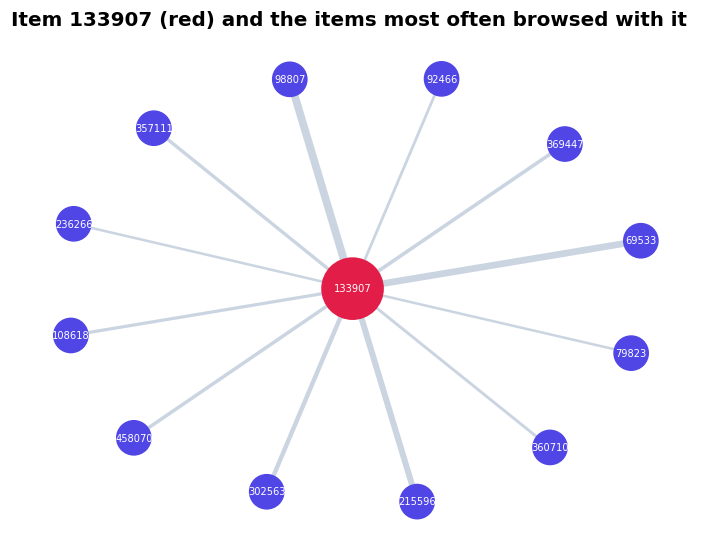

In [11]:
hub = deg.sort_values(ascending=False).index[40]            # a popular item (not the mega-hub, for legibility)
nb = edges[(edges["i"] == hub) | (edges["j"] == hub)].copy()
nb["other"] = np.where(nb["i"] == hub, nb["j"], nb["i"])
nb = nb[nb["other"] != hub].sort_values("count", ascending=False).head(12)

G = nx.Graph()
for _, r in nb.iterrows():
    G.add_edge(int(hub), int(r["other"]), w=int(r["count"]))

fig, ax = plt.subplots(figsize=(6.6, 5.2))
pos = nx.spring_layout(G, seed=7, k=0.9)
wmax = nb["count"].max()
widths = [0.6 + G[u][v]["w"] / wmax * 4.5 for u, v in G.edges()]
sizes = [1600 if n == hub else 500 for n in G.nodes()]
colors = [HILITE if n == hub else ACCENT for n in G.nodes()]
nx.draw_networkx_edges(G, pos, width=widths, edge_color=MUTED, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6.5, font_color="white", ax=ax)
ax.set_title(f"Item {hub} (red) and the items most often browsed with it")
ax.axis("off")
plt.tight_layout(); plt.show()

### 2.4 Why a graph *neural* network

Now the payoff, and the answer to "why graphs".

On its own, an item id is meaningless. Item 355908 is just a number. Its meaning comes entirely from **the company it keeps**: the products viewed around it, and the products viewed around *those*. The data handed us exactly one kind of signal, item-to-item co-occurrence, and a graph is the object that stores it losslessly.

A **graph neural network** is the model that reads this object the way it is meant to be read. Its one repeated operation is:

> each item updates its own representation by gathering information from its neighbors.

Stack that operation twice and an item hears not just from the products seen directly beside it, but from *their* neighbors too, a two-hop echo of the browsing patterns around it. That is precisely the structure we just built, turned into a computation. Nothing about it is arbitrary:

| Property of the data | Why a GNN fits |
| --- | --- |
| Only item-item relationships survive (no users) | A graph stores exactly those relationships |
| An item means little alone | Message passing defines an item *by its neighbors* |
| Co-occurrence is undirected and repeated | Undirected, weighted edges feed directly into aggregation |
| Sparse graph, cheap neighborhoods | Message passing touches only real neighbors, not all 82k items |

A model that treated items as independent (a plain lookup table, a bag of clicks) would throw away the single richest thing we have. The graph is the shape of the data itself, not a stylistic choice.

**But which graph network?** The simplest ones just average a node's neighbors (GraphSAGE), or weight them with local attention (GAT). On a graph with hub items, long tails, and sessions where *order* and *distant* items matter, plain neighbor-averaging leaves signal on the table. That gap is the reason for **Part 3: why a graph transformer specifically.**


---
## Part 3. Why a graph transformer specifically

Part 2 answered "why a graph". This part answers "why *this* graph model". We reach for a transformer for two concrete reasons, both about our graph: the power-law hubs, and the fact that structural *position* carries signal. Those are exactly what simpler graph networks cannot see.

We build the argument on a real slice of the item graph, then run the actual model class from the repo on it.


### 3.1 The ladder so far, and where it stalls

Every graph network answers one question: *when I update an item from its neighbors, how much does each neighbor count?* The project climbs a ladder of answers.

- **GraphSAGE** (`SAGEConv`, mean aggregator): every neighbor counts equally. An item becomes the average of its neighbors. Simple and surprisingly strong, but on a hub with hundreds of neighbors the average turns to mush, and the model cannot tell a defining co-view from a random one. **Recall@10: 14.8%.**
- **GAT** (`GATConv`): learn a weight per neighbor, so informative neighbors count more. This is *local* attention, and it helps. **Recall@10: 20.1%.**

Real gains, then a wall. Two limits survive, and both are about *our* data:

1. **Position blindness.** Message passing is permutation invariant. Two items with look-alike local neighborhoods are indistinguishable to a GNN, even if one is a central hub and the other sits on the rim. On a power-law graph that hub-versus-rim distinction is precisely the signal we want.
2. **Reach.** To let far-apart items influence each other you stack more layers, but stacking GNN layers oversmooths: after a few hops every node's vector converges toward the same thing.

The graph transformer attacks both. Let's pull a real subgraph to work on.


working subgraph: 35 items, 232 edges (a real piece of the 82k-node graph)


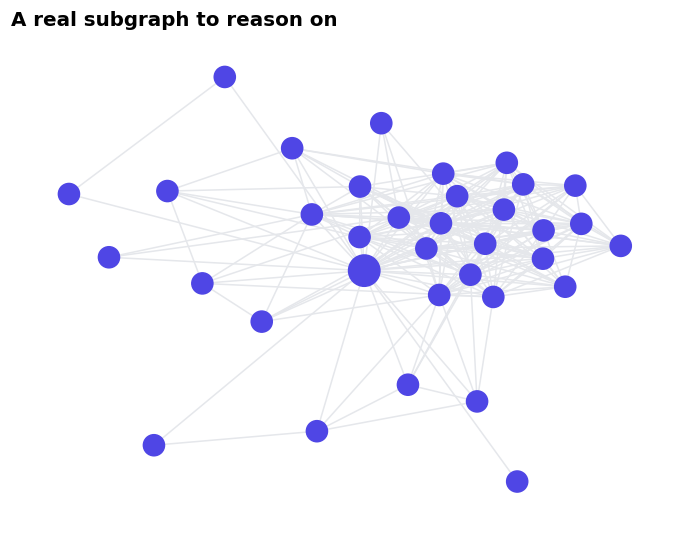

In [12]:
# grow a small, connected, real subgraph: a popular item and the items most tied to it
seed = int(deg.sort_values(ascending=False).index[8])
inc = edges[((edges["i"] == seed) | (edges["j"] == seed)) & (edges["i"] != edges["j"])].copy()
inc["other"] = np.where(inc["i"] == seed, inc["j"], inc["i"])
keep = set([seed] + inc.sort_values("count", ascending=False)["other"].head(34).astype(int).tolist())
sub = edges[(edges["i"].isin(keep)) & (edges["j"].isin(keep)) & (edges["i"] != edges["j"])]

G0 = nx.Graph()
G0.add_nodes_from(keep)
G0.add_edges_from(sub[["i", "j"]].to_numpy())
G0 = G0.subgraph(max(nx.connected_components(G0), key=len)).copy()   # keep the connected core
nodes = sorted(G0.nodes())
n = len(nodes)
print(f"working subgraph: {n} items, {G0.number_of_edges()} edges (a real piece of the 82k-node graph)")

pos = nx.spring_layout(G0, seed=3, k=0.55)
fig, ax = plt.subplots(figsize=(6.4, 5))
nx.draw_networkx_edges(G0, pos, edge_color="#e5e7eb", ax=ax)
nx.draw_networkx_nodes(G0, pos, node_color=ACCENT,
                       node_size=[420 if x == seed else 190 for x in G0.nodes()], ax=ax)
ax.set_title("A real subgraph to reason on")
ax.axis("off")
plt.tight_layout(); plt.show()

### 3.2 Addition one: attention as the aggregator (`TransformerConv`)

The transformer swaps mean or single-headed attention for the transformer's own **scaled dot-product, multi-head attention**, computed over each node's neighbors, plus a **gated residual** connection. In the repo:

```python
TransformerConv(embedding_dim, hidden_dim // num_heads,
                heads=num_heads, concat=True,
                beta=True)   # gated residual: learn how much to keep self vs take from neighbors
```

Two things this buys over GAT:

- **Multiple heads** look for different reasons two items go together (same category, same price band, bought-after), instead of one blended score.
- **The gate `beta`** lets each item decide, per layer, how much to trust its neighbors versus hold onto itself. That is what makes it safe to stack layers without collapsing, the oversmoothing problem from 3.1.

An honest scope note: this attention still runs over graph **neighbors**, not all 82k items at once (all-pairs attention on 82k nodes is not feasible). So the transformer does not get global reach from attention alone. It gets it from the second addition.


### 3.3 Addition two: Laplacian positional encoding (the math, computed live)

This is the piece that cures position blindness, and it is the real mathematics of the project.

Build the graph **Laplacian**. With adjacency $A$ and degree matrix $D$:

$$L = D - A, \qquad L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$

The eigenvectors of $L$ are the graph's natural coordinate system (its Fourier basis). The reason is one clean identity: for any signal $x$ on the nodes,

$$x^\top L x = \sum_{(i,j)\in E} (x_i - x_j)^2$$

The right side measures how much $x$ changes across edges. So eigenvectors with **small** eigenvalues are the **smoothest** functions on the graph: they vary slowly, hug the community structure, and act like low-frequency coordinates telling you *where* a node sits. Let's check that identity numerically before we trust it.


In [13]:
A = nx.to_numpy_array(G0, nodelist=nodes)     # unweighted 0/1 adjacency
d = A.sum(1)
L = np.diag(d) - A                             # combinatorial Laplacian

rng = np.random.default_rng(0)
x = rng.standard_normal(n)
quadratic_form = float(x @ L @ x)
edge_difference_sum = float(sum((x[i] - x[j]) ** 2 for i, j in
                                [(nodes.index(a), nodes.index(b)) for a, b in G0.edges()]))
print(f"x^T L x                    = {quadratic_form:.6f}")
print(f"sum over edges (xi - xj)^2 = {edge_difference_sum:.6f}")
print(f"equal? {np.isclose(quadratic_form, edge_difference_sum)}")

x^T L x                    = 288.635353
sum over edges (xi - xj)^2 = 288.635353
equal? True


/var/folders/xx/1nn8khpj6cq8cbxnnp0275zh0000gn/T/ipykernel_5910/3114209949.py:7: RuntimeWarning: divide by zero encountered in matmul
  quadratic_form = float(x @ L @ x)
/var/folders/xx/1nn8khpj6cq8cbxnnp0275zh0000gn/T/ipykernel_5910/3114209949.py:7: RuntimeWarning: overflow encountered in matmul
  quadratic_form = float(x @ L @ x)
/var/folders/xx/1nn8khpj6cq8cbxnnp0275zh0000gn/T/ipykernel_5910/3114209949.py:7: RuntimeWarning: invalid value encountered in matmul
  quadratic_form = float(x @ L @ x)


They match to machine precision. The Laplacian really does measure smoothness across edges, so its low eigenvectors really are the graph's coordinates. Now compute the symmetric-normalized version (the one the repo uses), drop the trivial first eigenvector (a flat constant, all nodes equal), and look at the next three as colors on the graph.


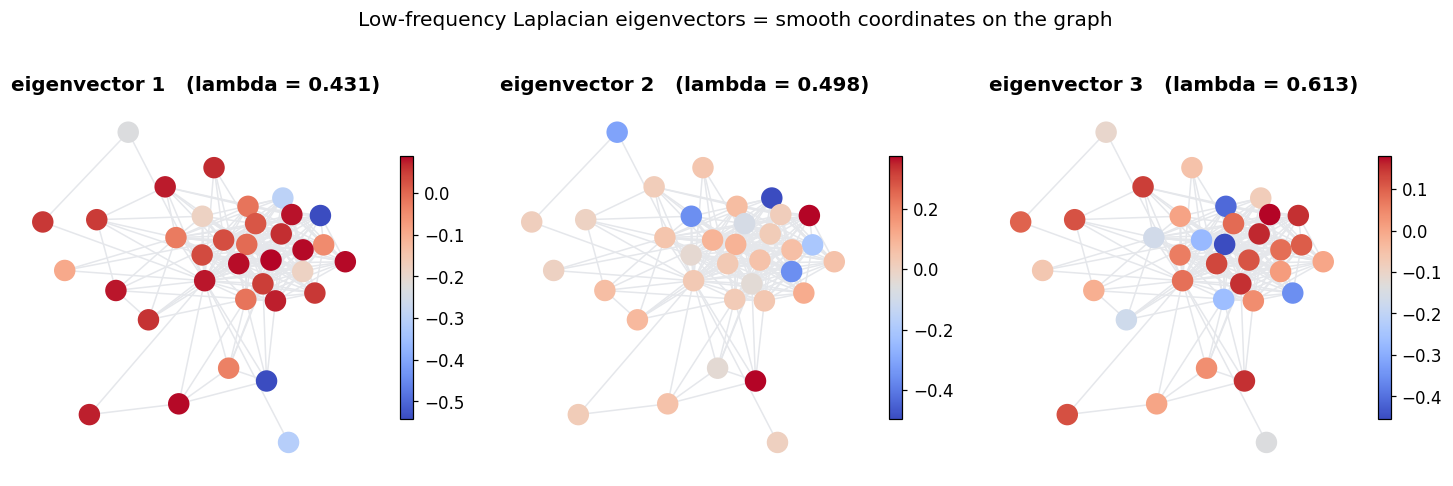

In [14]:
dinv = 1.0 / np.sqrt(np.maximum(d, 1e-9))
L_sym = np.eye(n) - (dinv[:, None] * A * dinv[None, :])
evals, evecs = np.linalg.eigh(L_sym)           # ascending eigenvalues

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
for t, ax in enumerate(axes):
    v = evecs[:, 1 + t]                        # skip eigenvector 0 (the trivial constant)
    nx.draw_networkx_edges(G0, pos, edge_color="#e5e7eb", ax=ax)
    nc = nx.draw_networkx_nodes(G0, pos, node_color=v, cmap="coolwarm",
                                node_size=170, ax=ax)
    ax.set_title(f"eigenvector {t + 1}   (lambda = {evals[1 + t]:.3f})")
    ax.axis("off")
    fig.colorbar(nc, ax=ax, shrink=0.7)
plt.suptitle("Low-frequency Laplacian eigenvectors = smooth coordinates on the graph", y=1.02)
plt.tight_layout(); plt.show()

Read the colors. Each eigenvector paints a smooth gradient across the graph: one side warm, the other cool, changing gently along the edges. That gradient *is* a position. Eigenvector 1 might separate two loose communities, eigenvector 2 a finer split, and so on. Stack the first $k$ of them and every node gets a $k$-dimensional structural address, its place in the graph, independent of what its immediate neighbors happen to be.

Two practical details, both visible in the repo's `laplacian_pe.py`:

- **Sign ambiguity.** An eigenvector and its negative are equally valid, so flipping every color would be just as correct. The code takes the absolute value to make the encoding stable.
- **How the model uses it.** The $k$ eigenvector values are projected up to the embedding size and simply **added** to the item embedding:

```python
lap_pe = self.laplacian_pe.project(batch.laplacian_pe)   # k -> embedding_dim
x = x + lap_pe
```

So before any attention runs, each item already carries *both* what it is (its learned embedding) and where it sits (its Laplacian coordinates). That is what a plain GNN never has.


### 3.4 Put it together, and run the real model

The full block is: **item embedding + Laplacian PE**, then for each layer **`TransformerConv` (attention over neighbors) into BatchNorm into a residual add**, optionally a feed-forward network, and finally a session readout that pools the item vectors into one session vector. Let's instantiate the actual optimized class from the repo and push our real subgraph through it.


In [15]:
import torch
from torch_geometric.data import Data
from etpgt.model import create_graph_transformer_optimized

K = 8
pe_for_model = np.abs(evecs[:, 1:1 + K]).astype("float32")   # k structural coordinates, sign fixed

model = create_graph_transformer_optimized(
    num_items=n + 1, embedding_dim=64, hidden_dim=64,
    num_layers=2, num_heads=2, use_laplacian_pe=True, laplacian_k=K,
).eval()

E_und = np.concatenate([np.array(list(G0.edges())), np.array(list(G0.edges()))[:, ::-1]])
relabel = {x: k for k, x in enumerate(nodes)}
edge_index = torch.tensor([[relabel[a], relabel[b]] for a, b in E_und], dtype=torch.long).t()

data = Data(x=torch.arange(1, n + 1), edge_index=edge_index)
data.batch = torch.zeros(n, dtype=torch.long)       # the whole subgraph is one "session"
data.laplacian_pe = torch.tensor(pe_for_model)

with torch.no_grad():
    session_vec = model(data)                        # pool items -> one session embedding
    top5 = model.predict(session_vec, k=5)           # score every item, take top 5

print(f"session embedding shape : {tuple(session_vec.shape)}")
print(f"top-5 item ids          : {top5[0].tolist()}   (UNTRAINED toy weights, values are noise)")
print(f"model parameters        : {sum(p.numel() for p in model.parameters()):,}")
print("\nThe point is not the numbers. It is that every piece from this part"
      "\n(embedding + Laplacian PE + neighbor attention + readout) runs end to end.")

session embedding shape : (1, 64)
top-5 item ids          : [33, 32, 31, 12, 2]   (UNTRAINED toy weights, values are noise)
model parameters        : 36,800

The point is not the numbers. It is that every piece from this part
(embedding + Laplacian PE + neighbor attention + readout) runs end to end.


The scores are meaningless here (random weights, a toy vocabulary), and that is fine. What matters is that the exact architecture we motivated runs end to end on real graph structure. Training, next, is what turns those random weights into a 38 percent recommender.

**Does the extra machinery actually pay off?** Here is the project's reported ladder.


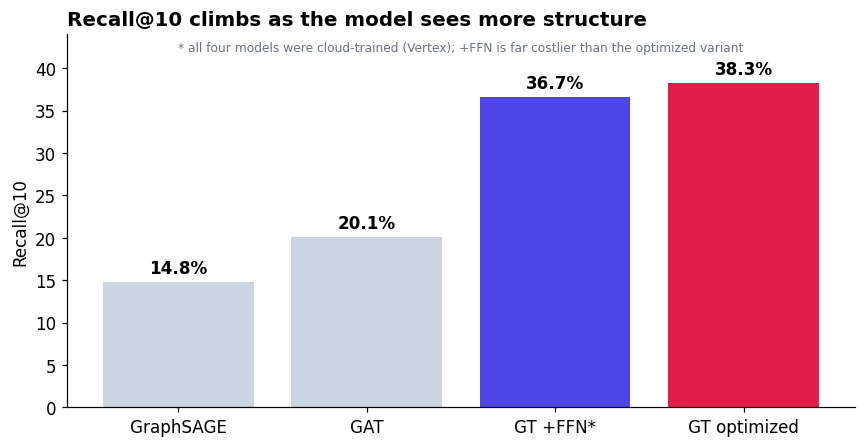

In [16]:
names = ["GraphSAGE", "GAT", "GT +FFN*", "GT optimized"]
recall = [14.79, 20.10, 36.66, 38.28]
bar_colors = [MUTED, MUTED, ACCENT, HILITE]

fig, ax = plt.subplots()
bars = ax.bar(names, recall, color=bar_colors)
ax.bar_label(bars, labels=[f"{r:.1f}%" for r in recall], padding=3, fontweight="bold")
ax.set_title("Recall@10 climbs as the model sees more structure")
ax.set_ylabel("Recall@10")
ax.set_ylim(0, 44)
ax.text(0, 42, "* all four models were cloud-trained (Vertex); +FFN is far costlier than the optimized variant",
        fontsize=8, color="#6b7280")
plt.tight_layout(); plt.show()

**One last twist, and it is the same lesson as the data.** All four models were trained on the cloud (a 16 GB laptop cannot touch a 466k-item embedding). The heaviest part of a standard transformer block is its feed-forward network. The optimized variant strips the FFN and cuts to two layers and two heads, which makes training dramatically cheaper (the project cites roughly $21 against a far larger estimate for the full-size model) and yet scores *higher*: **38.28 percent versus 36.66**. Just as the data shaped the model, the **compute budget shaped the architecture**, and measuring that tradeoff honestly is what turned a constraint into a better result.

### The story so far

We followed one unbroken thread. The data has no users, only anonymous sessions and the items in them (Part 1). That forces items-and-relationships, which is a graph, read by a graph neural network (Part 2). And the graph's hubs and positional signal force something stronger than neighbor averaging: attention over neighbors plus Laplacian positional encoding, the graph transformer (Part 3).

Next we **train** this model (the loss, and how we sample negatives from 82k items), then **serve** it behind an API. We now have the real cloud-trained checkpoints in the repo, so both of those parts will use the genuine 38.28 percent model, not a stand-in.